# Phase 7A Level 1S：训练稳定性消融

**目标**：不增加教师数据或模型复杂度，只比较三种网络结构与 Adam/LBFGS 的训练稳定性。数据、双冻结测试、MPC、1RC、约束、闭环初态和原验收门槛全部冻结。

只有选定方案的五个原种子全部通过双冻结测试与完整同模型闭环，才允许进入 Level 2。

## 1. 读取冻结结果

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
OUT = ROOT / 'outputs' / 'phase7a_level1s_training_stability'
DATA = ROOT / 'data' / 'phase7a_level1s_training_stability'
metrics = json.loads((OUT / 'metrics.json').read_text(encoding='utf-8'))
candidates = pd.read_csv(OUT / 'candidate_metrics.csv')
schemes = pd.read_csv(OUT / 'scheme_validation_summary.csv')
selected = pd.read_csv(OUT / 'selected_scheme_five_seed_metrics.csv')
closed = pd.read_csv(DATA / 'closed_loop_metrics.csv')
diagnostics = pd.read_csv(DATA / 'closed_loop_diagnostics_per_seed.csv')
print(metrics['study_name'], metrics['status'])

phase7a_level1s_training_stability completed


## 2. 诊断量定义

充电电流为正，采样周期为 \(\Delta t=5\,\mathrm{s}\)。累计电荷误差定义为

\[
\Delta Q=\frac{\Delta t}{3600}\left(\sum_{k=0}^{N_{\mathrm{DNN}}-1}I_k^{\mathrm{DNN}}-\sum_{k=0}^{N_{\mathrm{MPC}}-1}I_k^{\mathrm{MPC}}\right)\ \mathrm{Ah}.
\]

有符号步数差为

\[
\Delta N=N_{\mathrm{DNN}}-N_{\mathrm{MPC}},
\]

正值表示 DNN 更慢。离散到达时间差为 \(\Delta t_{\mathrm{disc}}=\Delta N\Delta t\)。若阈值 \(SOC_{\mathrm{th}}=0.7995\) 位于第 \(k\) 步的两个状态之间，连续穿越时间为

\[
t_{\mathrm{cross}}=k\Delta t+\Delta t\frac{SOC_{\mathrm{th}}-SOC_k}{SOC_{k+1}-SOC_k}.
\]

连续指标只诊断 5 s 采样量化，不替代原离散 2% 门槛。

## 3. 冻结合同

In [2]:
frozen = metrics['frozen_contract']
display(pd.DataFrame([{
    'all_sources_preserved': frozen['all_sources_preserved'],
    'closed_loop_initial_states_preserved': frozen['closed_loop_initial_states_preserved'],
    'no_new_teacher_data': frozen['no_new_teacher_data'],
}]))
assert frozen['all_sources_preserved']
assert frozen['closed_loop_initial_states_preserved']
assert frozen['no_new_teacher_data']

,all_sources_preserved,closed_loop_initial_states_preserved,no_new_teacher_data
0,True,True,True


## 4. 六种训练方案的验证集联合选择

,scheme,validation_nrmse,validation_abs_bias_a,validation_low_current_abs_bias_a,validation_rank_sum,selected
0,deep_32_32_16__lbfgs,0.002450,0.001502,0.010660,3.0,True
1,deep_32_32_16__adam,0.002898,0.004424,0.017797,6.0,False
2,shallow_16__lbfgs,0.006332,0.009194,0.037234,9.0,False
3,shallow_16__adam,0.010011,0.012297,0.038658,13.0,False
4,shallow_32__lbfgs,0.006812,0.013998,0.039390,15.0,False
5,shallow_32__adam,0.010089,0.012722,0.047939,17.0,False


Selected: deep_32_32_16__lbfgs


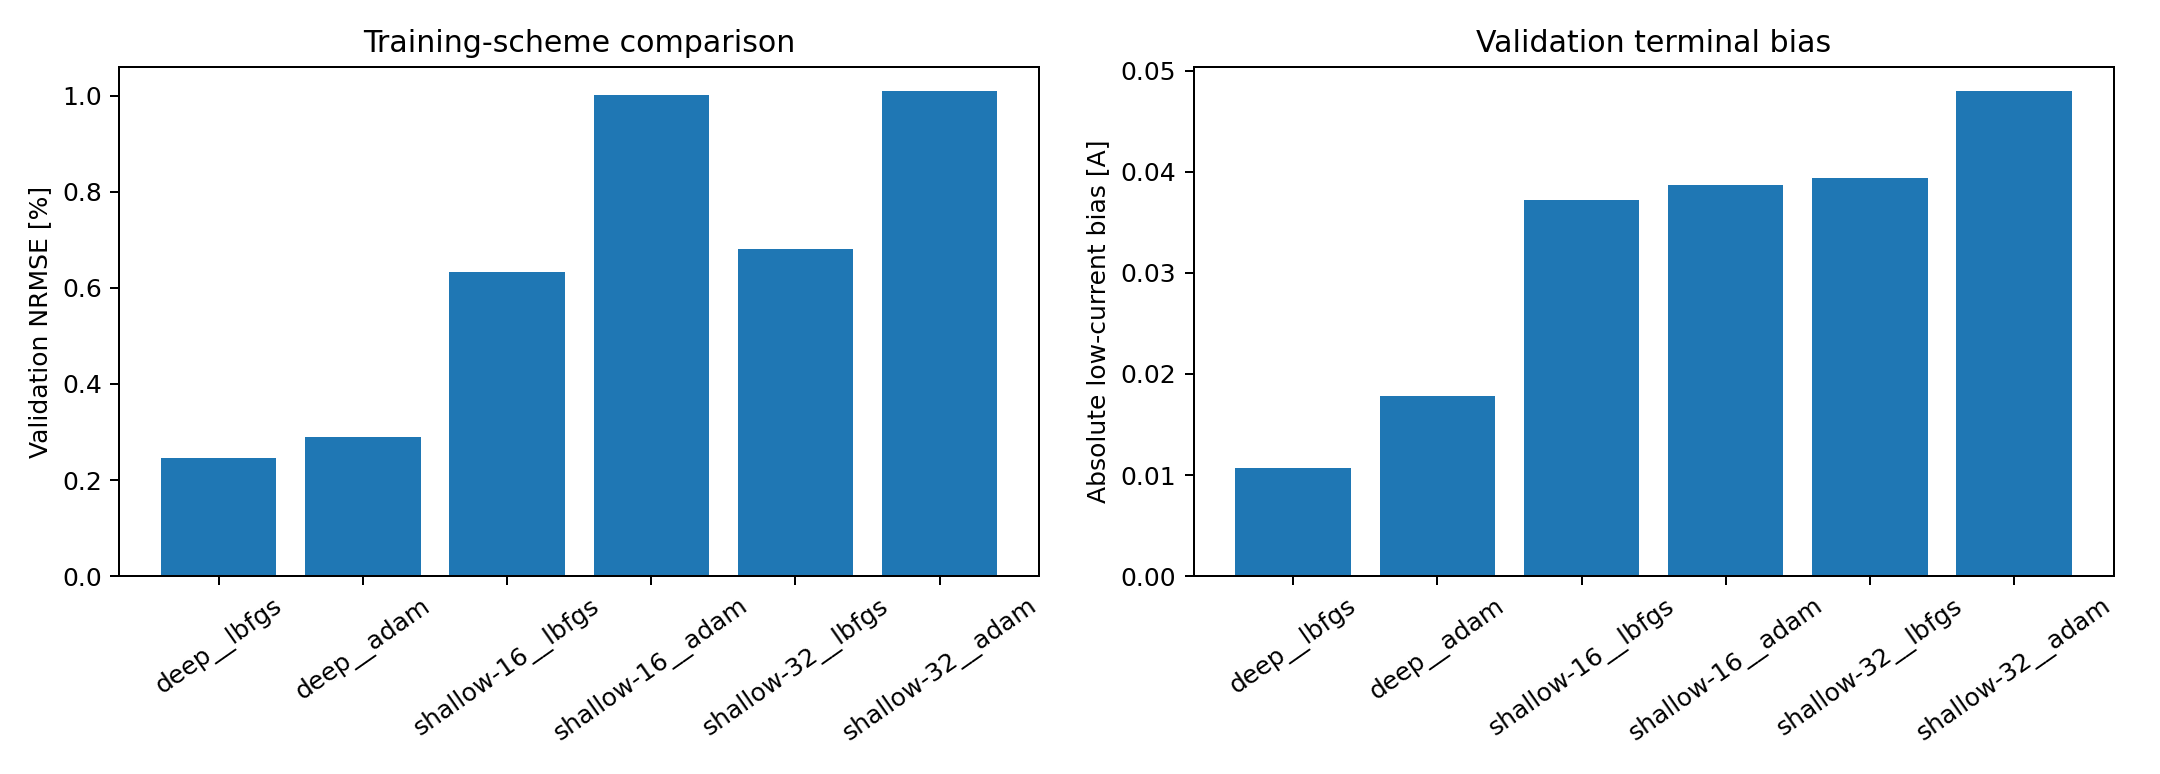

In [3]:
display(schemes[['scheme','validation_nrmse','validation_abs_bias_a','validation_low_current_abs_bias_a','validation_rank_sum','selected']])
print('Selected:', metrics['selection']['selected_scheme'])
assert len(candidates) == 30
assert metrics['selection']['selection_data'] == 'validation_only'
assert metrics['selection']['selected_scheme'] == 'deep_32_32_16__lbfgs'
display(Image(filename=str(OUT / 'figures' / 'scheme_selection.png')))

## 5. 选定方案的双冻结测试

In [4]:
view = selected[['seed','test_nrmse','terminal_test_nrmse','terminal_test_bias_a','terminal_test_low_current_bias_a']].copy()
view['original_test_nrmse_percent'] = 100 * view.pop('test_nrmse')
view['terminal_test_nrmse_percent'] = 100 * view.pop('terminal_test_nrmse')
display(view)
assert (view.original_test_nrmse_percent < 1).all()
assert (view.terminal_test_nrmse_percent < 1).all()

,seed,terminal_test_bias_a,terminal_test_low_current_bias_a,original_test_nrmse_percent,terminal_test_nrmse_percent
0,22,0.000117,-0.001192,0.173611,0.155040
1,42,0.000497,-0.001531,0.366595,0.193565
2,73,-0.001199,0.002836,0.371558,0.283564
3,101,-0.001072,0.004379,0.158363,0.193136
4,137,-0.000197,0.001355,0.237165,0.282032


## 6. 固定初态完整闭环

,seed,target_reach_fraction,maximum_voltage_violation_v,speedup,current_nrmse_percent,discrete_charge_time_gap_percent
0,22,1.0,0.0,1670.831802,0.166790,0.565440
1,42,1.0,0.0,1814.917371,0.349701,0.565440
2,73,1.0,0.0,1917.948464,0.351618,0.565440
3,101,1.0,0.0,1924.196843,0.184217,0.565440
4,137,1.0,0.0,1889.760220,0.251908,0.282171


,seed,mean_signed_step_difference,maximum_absolute_step_difference,mean_discrete_arrival_time_difference_s,mean_discrete_arrival_time_gap_fraction,mean_cumulative_charge_error_ah,mean_absolute_cumulative_charge_error_ah,mean_continuous_crossing_time_difference_s,mean_continuous_crossing_time_gap_fraction
0,22,1.0,1,5.0,0.005654,0.000028,0.000028,3.548295,0.003997
1,42,1.0,1,5.0,0.005654,0.000022,0.000022,3.735516,0.004201
2,73,-1.0,1,-5.0,0.005654,0.000016,0.000016,-5.330266,0.006071
3,101,-1.0,1,-5.0,0.005654,0.000027,0.000027,-5.823330,0.006632
4,137,-0.5,1,-2.5,0.002822,0.000054,0.000061,-4.283154,0.004863


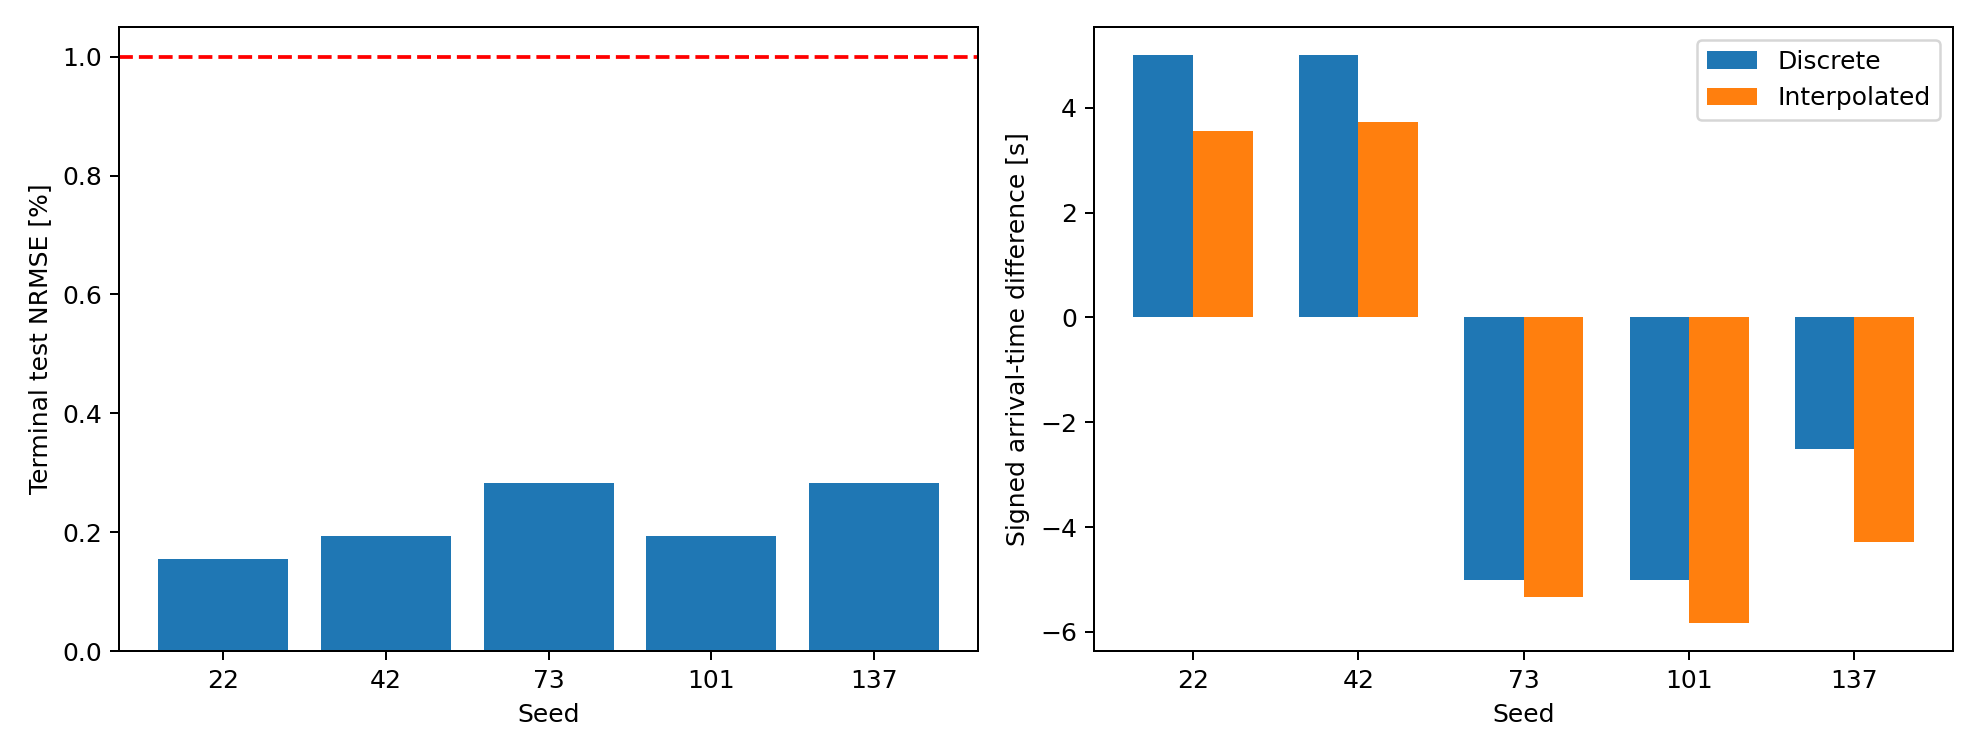

In [5]:
view = closed[['seed','mean_current_nrmse','mean_charge_time_gap_fraction','target_reach_fraction','maximum_voltage_violation_v','speedup']].copy()
view['current_nrmse_percent'] = 100 * view.pop('mean_current_nrmse')
view['discrete_charge_time_gap_percent'] = 100 * view.pop('mean_charge_time_gap_fraction')
display(view)
display(diagnostics)
display(Image(filename=str(OUT / 'figures' / 'selected_scheme_closed_loop.png')))
assert (view.current_nrmse_percent < 1).all()
assert (view.discrete_charge_time_gap_percent < 2).all()

## 7. 最终判定

In [6]:
display(pd.DataFrame([metrics['decision']['checks']]))
print(metrics['decision']['conclusion'])
print('进入 Level 2:', metrics['decision']['proceed_to_level2'])
assert metrics['decision']['level1s_success']
assert metrics['decision']['proceed_to_level2']

,frozen_contract_preserved,dual_offline_tests_passed,same_model_closed_loop_passed
0,True,True,True


Level 1S 训练稳定性修复通过
进入 Level 2: True


## 结论

Level 1R 不是模型不可学习的实质失败：策略拟合、闭环电流、安全性和计算速度均已通过，剩余问题是训练随机性造成的终端到达时间一致性。Level 1S 在不改变数据和控制问题的前提下，以深层网络加 LBFGS 消除了该不稳定性，五个原种子全部通过原离散门槛。